# TP1 PROCESAMIENTO DEL HABLA: webscrapping

**Crea una copia de este notebook en tu google colab**

**Renombra el notebook con el siguiente formato APELLIDO_NOMBRE_PH_TP1.ipynb**

**[Jesús Agustin Centeno.]**


* Resolver las consignas comentando el código fuente, indicando desde dónde fue extraido o generado.

* Explicar y justificar cada paso realizado usando los bloques de texto.

* Publique enlace público a su notebook en google colab y también enlace a su repositorio github de la materia.


## EJERCICIO CONSIGNA

* Cree una nube de palabras de un texto en español.

* Dicho texto puede ser descargado de Internet (webscrapping) o extraído del dataset de alguna librería.

* Puede usar cualquier libreria o herramienta para obtener el texto de su interés.

* En este notebook explica el paso a paso del proceso.



## 1- Webscrapping

Extrae un texto de Internet de una sóla página web usando alguna de las técnicas de webscrapping vistas en clase. Busca el discurso de alguna persona quien te inspire o haya dado una charla motivadora.

No puedes repetir ni usar ni el mismo texto ni la misma web que otra persona quien ya entregó en el foro.

Abajo añade los bloques de código y texto necesarios. Explica paso a paso como descargaste el texto de tu interés.


In [6]:
!pip install pdfplumber pymupdf pandas requests -q

import io # Needed for BytesIO to open PDF content from memory
import requests
import pdfplumber
import pymupdf          # PyMuPDF. Forma equivalente y muy usada: "import fitz"
import pandas as pd
import os

print("pdfplumber:", pdfplumber.__version__)
print("pymupdf:", pymupdf.__doc__.splitlines()[0] if pymupdf.__doc__ else pymupdf.version)
print("pandas:", pd.__version__)

import time # Import the time module for delays
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer

# Descargar recursos necesarios
# 'punkt' y 'punkt_tab' son necesarios para la tokenización
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

print("Recursos de NLTK descargados correctamente.")




# 1. URL del archivo PDF (la URL ya apunta directamente a un PDF)
url_pagina = "https://xamanek.izt.uam.mx/map/cursos/Turing-Pensar.pdf"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
}

# La URL ya es un PDF directo, así que no se necesita Beautiful Soup para extraer el enlace.
pdf_url = url_pagina
print(f"URL del PDF detectada directamente: {pdf_url}")

# 3. Descargar el archivo PDF directamente en memoria
pdf_response = requests.get(pdf_url, headers=headers)

# 4. Extraer texto de las páginas del PDF usando pdfplumber
textos_originales_con_indices = []
try:
    with pdfplumber.open(io.BytesIO(pdf_response.content)) as pdf:
        num_pages = len(pdf.pages)
        selected_indices = set()

        if num_pages >= 10: # Si hay 10 páginas o menos, procesar todas
            for i in range(num_pages):
                selected_indices.add(i)
        else: # Seleccionar las primeras 5 y las últimas 5
            for i in range(5): # Primeras 5 páginas
                selected_indices.add(i)
            for i in range(num_pages - 5, num_pages): # Últimas 5 páginas
                selected_indices.add(i)

        # Convertir el conjunto de índices a una lista ordenada de tuplas (indice, objeto_pagina)
        selected_pages_with_indices = sorted([(idx, pdf.pages[idx]) for idx in selected_indices], key=lambda x: x[0])

        for original_idx, page_obj in selected_pages_with_indices:
            # Extraer texto de la página. Si no hay texto, extract_text() devuelve None.
            texto = page_obj.extract_text()
            textos_originales_con_indices.append((original_idx + 1, texto if texto else ""))
except Exception as e:
    print(f"Error al procesar PDF con pdfplumber: {e}")


texto_extraido_formateado = [] # Renombrado para claridad
cantidad_paginas=[]
for page_num, texto_content in textos_originales_con_indices:
    texto_extraido_formateado.append(f"=== PÁGINA {page_num} (Original) ===\n{texto_content}\n")
    cantidad_paginas.append(page_num)

# Unir todos los textos extraídos en una sola cadena para el procesamiento NLP
texto_completo_string = "\n".join([item.split('=== PÁGINA', 1)[1] if '=== PÁGINA' in item else item for item in texto_extraido_formateado])

# 5. Guardar el resultado en un archivo de texto
with open("documento_turing.txt", "w", encoding="utf-8") as f:
    f.writelines(texto_extraido_formateado)

print(f"Cantidad de paginas {cantidad_paginas[-1]}")
print("Extracción de texto original completada con éxito.")
print(texto_extraido_formateado) # Imprimir el contenido formateado



pdfplumber: 0.11.10
pymupdf: PyMuPDF 1.28.2: Python bindings for the MuPDF 1.28.2 library.
pandas: 2.2.3
Recursos de NLTK descargados correctamente.
URL del PDF detectada directamente: https://xamanek.izt.uam.mx/map/cursos/Turing-Pensar.pdf


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Cantidad de paginas 22
Extracción de texto original completada con éxito.
['=== PÁGINA 1 (Original) ===\nMaquinaria computacional e interrogador se le permite hacer preguntas tanto\nInteligencia a A como B del tipo:\nAlan Turing, 1950 C: X, ¿Sería tan amable de decirme el largo su\nTraductor: Cristóbal Fuentes Barassi, 2010, cabello?\nUniversidad de Chile.\nAhora, suponga que X es de hecho A, por lo que\nA debe responder. El objetivo de A en el juego\nes tratar de que C haga una identificación falsa.\n1. El juego de la imitación. Por lo que su respuesta podría ser:\n“Mi pelo está cortado en capas, y los mechones\nPropongo considerar la siguiente pregunta: más largos tienen unos 20 centímetros”.\n“¿Pueden pensar las máquinas?”. Se debiera co-\nPara que los tonos de voz no ayuden al interro-\nmenzar definiendo el significado de los términos\ngador, las respuestas deben ser escritas, o mejor\n‘máquina’ y ‘pensar’. Estas definiciones deberían\naún, tecleadas. Las condiciones ideales deberí

## 2- Preprocesamiento

### 2.1 Muestra las stop words que tenga tu texto.

In [ ]:
tokens = word_tokenize(texto_completo_string.lower(), language='spanish')

# 2. Stop Words: Eliminar palabras comunes que no aportan mucho significado (ej: 'los', 'de', 'en')
lista_stop_words = set(stopwords.words('spanish'))


print(lista_stop_words)

{'serías', 'teníamos', 'nosotras', 'habidos', 'esas', 'estos', 'esos', 'una', 'mis', 'fuimos', 'eran', 'estamos', 'estabas', 'eras', 'estés', 'hubiesen', 'habiendo', 'me', 'tendríais', 'ella', 'tiene', 'tuviesen', 'seré', 'estaremos', 'tuyas', 'sois', 'como', 'estuvieran', 'habría', 'uno', 'estabais', 'esta', 'han', 'tendrás', 'hemos', 'nuestras', 'les', 'serán', 'hubiésemos', 'tuve', 'estuvieses', 'hubieron', 'somos', 'tendrá', 'estado', 'todos', 'estaréis', 'había', 'algunos', 'tanto', 'los', 'habríais', 'estará', 'hay', 'sentida', 'suyas', 'suyos', 'ha', 'ya', 'tuya', 'estuvieseis', 'su', 'tú', 'fuera', 'tuvieseis', 'tuvo', 'tengas', 'que', 'tenida', 'estas', 'fuiste', 'habremos', 'estada', 'todo', 'habéis', 'habían', 'fuese', 'habíais', 'míos', 'estando', 'no', 'estuviera', 'nuestros', 'estuvierais', 'son', 'qué', 'hayas', 'estar', 'por', 'las', 'estaría', 'estén', 'tuvieron', 'unos', 'vosotras', 'están', 'sentidos', 'sería', 'habré', 'tuviésemos', 'estaríamos', 'hubiese', 'un', 'h

### 2.2 Quita las stop-words, caracteres extraños del texto. Utiliza el texto restante para crear una nube de palabras. Usa la biblioteca worldcloud de python.

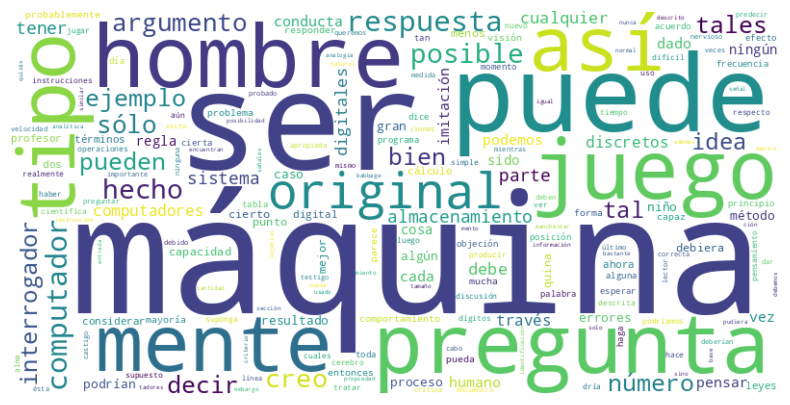

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
from nltk.corpus import stopwords # Asegurarse de que stopwords de NLTK esté importado

filtrados = [word for word in tokens if word.isalpha() and word not in lista_stop_words]
stemmer = SnowballStemmer('spanish')
stems = [stemmer.stem(word) for word in filtrados]

# Inicializar mis_stopwords con las stop words en español de NLTK
mis_stopwords = set(stopwords.words('spanish'))

palabras_a_excluir = {
    "de",
    "la",
    "que",
    "el",
    "en",
    "un",
    "los",
    "del",
    "se",
    "las",
    "por",
    "con",
    "para",
    "como",
    "este",
    "hola",
    "basura_var",
    "podría",
    "hacer",
    "manera",
    "esta"
}

mis_stopwords.update(palabras_a_excluir)

# Unir las palabras filtradas en una sola cadena para WordCloud
texto_para_wordcloud = " ".join(filtrados)

# 2. Configurar WordCloud
wc = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords=mis_stopwords,  # Filtra las palabras de la lista
    # Expresión regular: solo acepta palabras en español de 3 o más letras
    # Esto elimina automáticamente números, símbolos y códigos raros cortos (ej: x89a, ?, 123)
    regexp=r"\b[a-zA-ZáéíóúÁÉÍÓÚñÑ]{3,}\b",
    collocations=False,  # Evita repetir palabras compuestas/duplicadas
).generate(texto_para_wordcloud)

# 3. Visualizar
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

### 2.3 Usando el texto que conseguiste en el punto 1).



#### 2.3.1 Limpia y preprocesa el texto, descomponelo en oraciones, arma una matriz documento-vocabulario.


In [ ]:
import nltk
import pandas as pd
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer

nltk.download("punkt")
nltk.download("stopwords")

# 2. Descomponer el texto en oraciones
oraciones = nltk.sent_tokenize(texto_completo_string, language="spanish")

# 3. Obtener la lista de stopwords en español
spanish_stopwords = stopwords.words("spanish")

# 4. Crear el vectorizador y configurar la limpieza
# CountVectorizer convierte a minúsculas y quita puntuación por defecto
vectorizer = CountVectorizer(
    stop_words=spanish_stopwords,  # Elimina palabras vacías (de, la, que, etc.)
    token_pattern=r"\b[a-zA-ZáéíóúÁÉÍÓÚñÑ]{2,}\b",  # Solo palabras de al menos 2 letras (sin números ni símbolos)
    lowercase=True,
)

# 5. Transformar las oraciones en la matriz Documento-Vocabulario
matriz_sparse = vectorizer.fit_transform(oraciones)

# 6. Convertir a DataFrame de Pandas para visualizarlo fácilmente
vocabulario = vectorizer.get_feature_names_out()
df_matriz = pd.DataFrame(
    matriz_sparse.toarray(),
    columns=vocabulario,
    index=[f"Oración {i+1}" for i in range(len(oraciones))],
)

# Mostrar resultado
print("Oraciones detectadas:")
for i, oracion in enumerate(oraciones, 1):
    print(f"{i}: {oracion}")

print("\nMatriz Documento-Vocabulario (Frecuencia de palabras):")
print(df_matriz)

top_palabras = df_matriz.sum().sort_values(ascending=False).head(15)
print("Palabras con mayor frecuencia:")
print(top_palabras)

Oraciones detectadas:
1:  1 (Original) ===
Maquinaria computacional e interrogador se le permite hacer preguntas tanto
Inteligencia a A como B del tipo:
Alan Turing, 1950 C: X, ¿Sería tan amable de decirme el largo su
Traductor: Cristóbal Fuentes Barassi, 2010, cabello?
2: Universidad de Chile.
3: Ahora, suponga que X es de hecho A, por lo que
A debe responder.
4: El objetivo de A en el juego
es tratar de que C haga una identificación falsa.
5: 1.
6: El juego de la imitación.
7: Por lo que su respuesta podría ser:
“Mi pelo está cortado en capas, y los mechones
Propongo considerar la siguiente pregunta: más largos tienen unos 20 centímetros”.
8: “¿Pueden pensar las máquinas?”.
9: Se debiera co-
Para que los tonos de voz no ayuden al interro-
menzar definiendo el significado de los términos
gador, las respuestas deben ser escritas, o mejor
‘máquina’ y ‘pensar’.
10: Estas definiciones deberían
aún, tecleadas.
11: Las condiciones ideales deberían
ser elaboradas de manera tal que reflejen l

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



#### 2.3.2 Determina la longitud de tu vocabulario.

In [ ]:
longitud_vocabulario = len(df_matriz.columns)
print(f"Longitud del vocabulario: {longitud_vocabulario}")

#o la otra opción es consultando al diccionario interno del vectorizador

longitud_vocabulario = len(vectorizer.vocabulary_)

print(f"Longitud del vocabulario: {longitud_vocabulario}")

Longitud del vocabulario: 2673
Longitud del vocabulario: 2673



#### 2.3.3. Aplica TF-IDF a tu matriz documento-vocabulario

In [ ]:
from sklearn.feature_extraction.text import TfidfTransformer
# 1. Crear el transformador TF-IDF
tfidf_transformer = TfidfTransformer()

# 2. Aplicarlo a la matriz dispersa que ya tenías generada con CountVectorizer
matriz_tfidf_sparse = tfidf_transformer.fit_transform(matriz_sparse)

# 3. Convertir a DataFrame usando las mismas columnas de tu vocabulario
df_tfidf = pd.DataFrame(
    matriz_tfidf_sparse.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=[f"Oración {i+1}" for i in range(len(oraciones))],
)

# Ahora los valores irán de 0.0 a 1.0 según la importancia de la palabra
print(df_tfidf.head())

top_importantes = df_tfidf.mean().sort_values(ascending=False).head(10)
print(top_importantes)

           aaceptareljuegodelaimitacióncomounaprue  aban  abandonar  \
Oración 1                                      0.0   0.0        0.0   
Oración 2                                      0.0   0.0        0.0   
Oración 3                                      0.0   0.0        0.0   
Oración 4                                      0.0   0.0        0.0   
Oración 5                                      0.0   0.0        0.0   

           abandonarlo  abier  abre  abrumadora  absoluta  absoluto  \
Oración 1          0.0    0.0   0.0         0.0       0.0       0.0   
Oración 2          0.0    0.0   0.0         0.0       0.0       0.0   
Oración 3          0.0    0.0   0.0         0.0       0.0       0.0   
Oración 4          0.0    0.0   0.0         0.0       0.0       0.0   
Oración 5          0.0    0.0   0.0         0.0       0.0       0.0   

           abstracta  ...  última  últimas  último  últimos  única  \
Oración 1        0.0  ...     0.0      0.0     0.0      0.0    0.0   
Oració

Explica el formato de tu matriz resultante: documentos, vocabulario, tamaño. Brinda tus conclusiones.

# Conclusiones

Agregue aquí sus conclusiones sobre este trabajo práctico. Puede ser también parte del texto que posteará en el foro.

#Conclusión final

Para este trabajo práctico tome como ejemplo el articulo de Alan Turing:el juego de la imitación, articulo que cobra relevancia ante el contexto actual del avance de la IA y su posible futuro
El articulo plantea el tema de la inteligencia artificial y si los sistemas pueden superar a la inteligencia humana.
Para procesar este articulo se aplico pdfplumber para consumir el archivo que estaba subido sobre web para despues aplicar preprocesamiento y limpieza de texto con nltk
Tokenizando el texto, limpiandolo de caracteres especiales y quitandole las stopwords que no nos suman en el analisis
posteriormente se detecto y agrupo las distintas oraciones en una matriz documento-vocabulario a travez de tf-idf para detectar las palabras mas importantes que aparecen en el texto haciendo un previo analisis del vocabulario presente
Validando asi un flujo completo y automatico que permite escalar el analisis y validación de documentos




# Anexo, código de ejemplo del uso de wordcloud

Instalar e importar la librería

In [ ]:
# instalar wordcloud
!pip install wordcloud


In [ ]:

# Importar librerías
from wordcloud import WordCloud
import matplotlib.pyplot as plt


In [ ]:

# Texto de ejemplo
text = "Este es un texto de ejemplo para crear una nube de palabras usando word cloud. Puedes reemplazar este texto utilizando tu propio texto."

# Crear un objeto WordCloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)


Mostramos la imagen generada

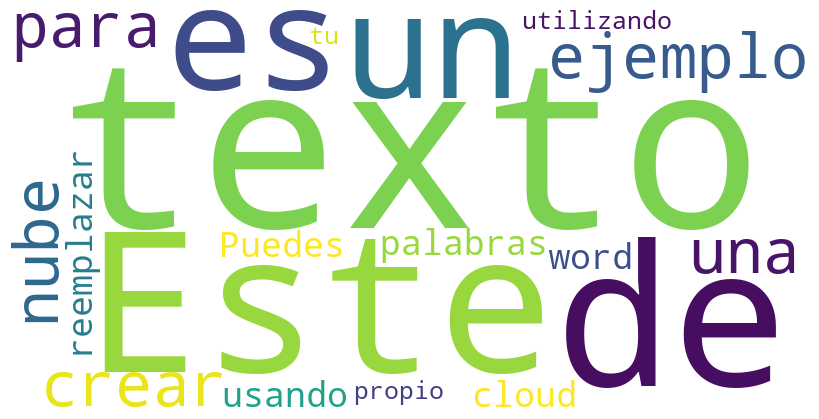

In [ ]:

# mostramos la imagen generada
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

Modificamos el ejemplo anterior agregando palabras en español que no queremos que considere para crear la nube de palabras. Estas son las stop_words



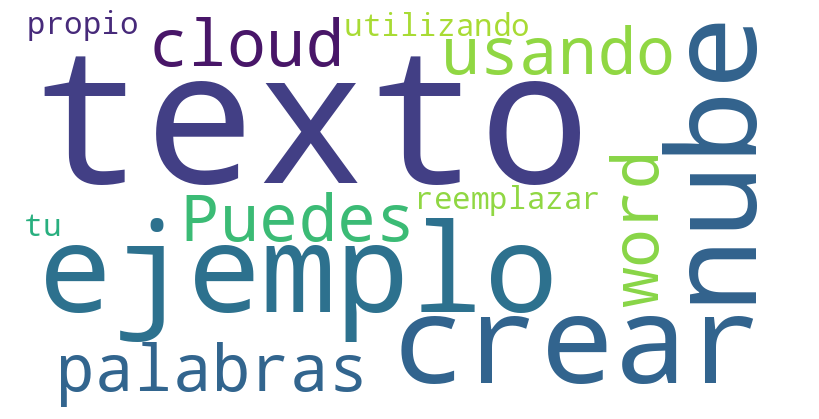

In [ ]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Texto de ejemplo
text = "Este es un texto de ejemplo para crear una nube de palabras usando word cloud. Puedes reemplazar este texto utilizando tu propio texto."

# Definir stopwords en español
stopwords_es = set(STOPWORDS)
stopwords_es.update(["con", "que", "los", "para", "un", "una", "el", "la", "en", "y", "o", "de", "a", "se", "es", "al", "como", "por", "no", "su", "más", "pero", "si", "este", "esta", "eso", "esa", "todo", "todos", "todas", "cada", "cual", "cualquier", "algo", "alguna", "algún", "ningún", "ninguna", "ninguno", "otro", "otros", "otras", "sobre", "entre", "durante", "desde", "hasta", "también", "así", "mismo", "misma", "mismo", "misma", "tan", "tanto", "tanta", "muy", "poco", "poca", "poco", "nada", "solo", "sola", "solo", "sola", "siempre", "nunca", "jamás", "casi", "aproximadamente", "cerca", "lejos", "antes", "después", "ahora", "hoy", "ayer", "mañana", "luego", "mientras", "mientras tanto", "después de", "antes de", "durante", "sin", "aunque", "a pesar de", "debido a", "gracias a", "por qué", "cómo", "dónde", "cuándo", "quién", "qué", "cuál"])

# Crear un objeto WordCloud con stopwords en español
wordcloud = WordCloud(width=800, height=400, background_color="white", stopwords=stopwords_es).generate(text)

# Mostramos la imagen generada
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()
